In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearnex import patch_sklearn
patch_sklearn()
import os
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier,RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.model_selection import train_test_split
import shap

from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score,classification_report


Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [2]:
base_dir = '../'
fibseg_dir = os.path.join(base_dir, 'fiber_segmentation_processed_data')


In [23]:
collagen_tb = pd.read_csv(os.path.join(fibseg_dir,'fiber_object_table.csv'))
collagen_tb.dropna(axis =0, inplace=True)
collagen_tb = collagen_tb[np.isfinite(collagen_tb.alignment_score)]#drop non finite elements
collagen_tb['Leap_ID'] = collagen_tb.fov.str.split('_',n = 1).str[0].str.upper()
biosamples_path = '/home/giuseppe/devices/Delta_Tissue/IMC/IMC_data/ExtraDocs/processed_response_RCB.csv'
biosamples =pd.read_csv(biosamples_path)
collagen_tb = collagen_tb.merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)#add metadata on patient
collagen_tb = collagen_tb[collagen_tb['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE']

In [24]:
X = collagen_tb[['major_axis_length',
       'minor_axis_length', 'orientation', 'area', 'eccentricity',
       'euler_number', 'alignment_score','Leap_ID']].groupby(by = 'Leap_ID').mean()
y = collagen_tb[['Leap_ID','new_Response']].drop_duplicates().set_index('Leap_ID')
y['new_Response'] = y.new_Response.replace('enR','nR')
y = X.merge(y,left_index=True,right_index=True)['new_Response']

In [25]:

le = LabelEncoder()
y = le.fit_transform(y)
le.inverse_transform([0,1])

array(['nR', 'pCR'], dtype=object)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(   X, y, test_size=0.33)

In [92]:
param_distributions1 = {
   # 'preprocessor__hashenc__n_features':[4,10,20,100,1000],
    'max_features': [1, 5,10,20,50 ,100,None],
    "max_leaf_nodes": [10, 100, 1000, None],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50, 100],
}
clf = RandomForestClassifier(class_weight="balanced")
#regr.fit(X_train, y_train)
search_cv1 = RandomizedSearchCV(
    clf,
    param_distributions=param_distributions1,
    scoring='f1_weighted',
    n_iter=1000,
    random_state=0,
    cv = 10,
    n_jobs=-1,
    refit=lambda cv_results:(pd.DataFrame(cv_results)['mean_test_score']-pd.DataFrame(cv_results)['std_test_score']).idxmax()
)
search_cv1.fit(X_train, y_train)



The total space of parameters 196 is smaller than n_iter=1000. Running 196 iterations. For exhaustive searches, use GridSearchCV.
/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: User

RandomizedSearchCV(cv=10,
                   estimator=RandomForestClassifier(class_weight='balanced'),
                   n_iter=1000, n_jobs=-1,
                   param_distributions={'max_features': [1, 5, 10, 20, 50, 100,
                                                         None],
                                        'max_leaf_nodes': [10, 100, 1000, None],
                                        'min_samples_leaf': [1, 2, 5, 10, 20,
                                                             50, 100]},
                   random_state=0, refit=<function <lambda> at 0x7f70b5a2edc0>,
                   scoring='f1_weighted')

In [93]:
def format_cv_results(param_distributions,search_cv):
    columns = [f"param_{name}" for name in param_distributions.keys()]
    columns += ["mean_test_score", "std_test_score"]
    cv_results = pd.DataFrame(search_cv.cv_results_)
    #cv_results["mean_test_error"] = -cv_results["mean_test_score"]
    #cv_results["std_test_error"] = cv_results["std_test_score"]
    
    return cv_results[columns].sort_values(by="mean_test_score").iloc[:-10:-1],cv_results
cv_results_filt,cv_results1 = format_cv_results(param_distributions1,search_cv1)
cv_results_filt

,param_max_features,param_max_leaf_nodes,param_min_samples_leaf,mean_test_score,std_test_score
24,1,None,10,0.703333,0.241500
2,1,10,5,0.663333,0.244245
15,1,1000,2,0.626667,0.339215
94,20,100,10,0.623333,0.319044
3,1,10,10,0.620000,0.234852
1,1,10,2,0.613333,0.304120
170,None,10,5,0.613333,0.304120
7,1,100,1,0.610000,0.348983
91,20,100,1,0.610000,0.281287


In [71]:
cv_results1.mean_test_score-cv_results1.std_test_score

0      0.336311
1      0.392937
2      0.361693
3      0.303582
4      0.233333
         ...   
191    0.231769
192    0.228497
193    0.254407
194    0.293333
195    0.254407
Length: 196, dtype: float64

In [94]:
y_pred = search_cv1.predict(X_test)
y_score = search_cv1.predict_proba(X_test)[:,1]
aucroc = roc_auc_score(y_test, y_score)
accuracy = accuracy_score(y_test, y_pred)
f1_ = f1_score(y_test, y_pred)
bal_acc_ = balanced_accuracy_score(y_test, y_pred)
mode = 'Test'
pcriterion = 'majority'
metrics = {
        f"{mode} Accuracy {pcriterion}": accuracy,
        f"{mode} AUC {pcriterion}": aucroc,
        f"{mode} F1 Score {pcriterion}": f1_,
        f"{mode} Balanced Accuracy": bal_acc_,
}
pd.Series(metrics)

X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names


Test Accuracy majority    0.650000
Test AUC majority         0.635417
Test F1 Score majority    0.588235
Test Balanced Accuracy    0.645833
dtype: float64

In [95]:
print(classification_report(y_train, search_cv1.predict(X_train)))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81        20
           1       0.81      0.72      0.76        18

    accuracy                           0.79        38
   macro avg       0.79      0.79      0.79        38
weighted avg       0.79      0.79      0.79        38



X does not have valid feature names, but RandomForestClassifier was fitted with feature names


In [96]:
from sklearn.metrics import f1_score

In [97]:
print(classification_report(y_test, search_cv1.predict(X_test)))

              precision    recall  f1-score   support

           0       0.73      0.67      0.70        12
           1       0.56      0.62      0.59         8

    accuracy                           0.65        20
   macro avg       0.64      0.65      0.64        20
weighted avg       0.66      0.65      0.65        20



X does not have valid feature names, but RandomForestClassifier was fitted with feature names


In [31]:
model = search_cv1.best_estimator_
model.n_classes_

2

In [98]:

explainer = shap.TreeExplainer(model,X_test,feature_names=model.feature_names_in_)
shap_values = explainer(X_test)[:,:,1]#shap values positive class

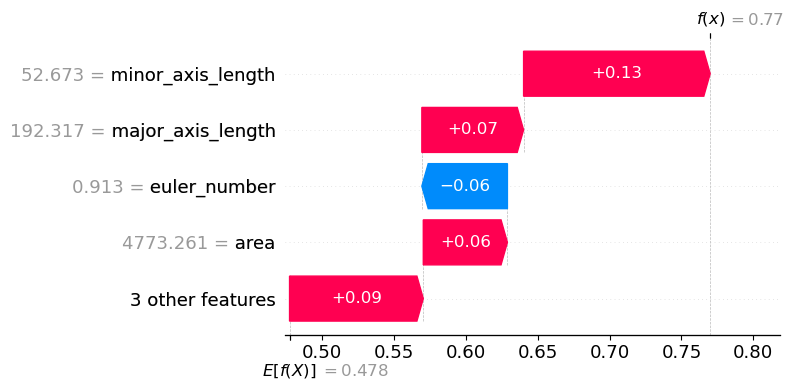

In [99]:
shap.plots.waterfall(shap_values[0], max_display=5,show=False)
plt.tight_layout()
plt.show()
#plt.savefig('figures/shap_waterfall.png')

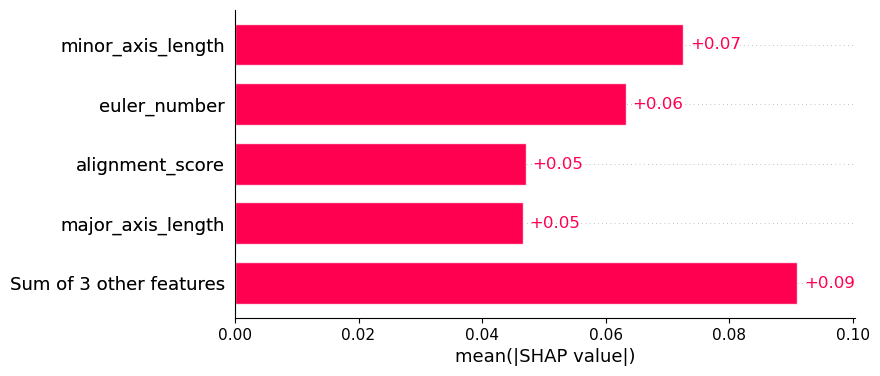

In [100]:
shap.plots.bar(shap_values,max_display=5)

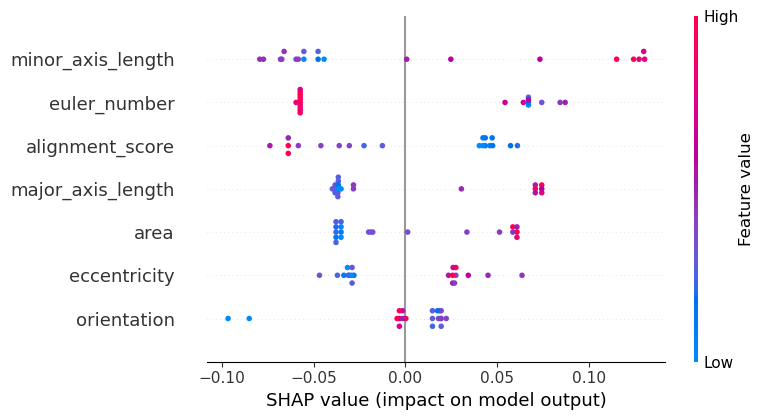

In [101]:

shap.summary_plot(shap_values,show=True)


### Xgboost

In [102]:
from xgboost import XGBClassifier

In [107]:
param_distributions1 = {
   # 'preprocessor__hashenc__n_features':[4,10,20,100,1000],
    'max_depth': [2, 4,6,10,50],
    'eta' : [0.1,0.3,0.5,0.7,0.9]
}
booster = XGBClassifier(class_weight="balanced")
#regr.fit(X_train, y_train)
search_cv2 = RandomizedSearchCV(
    booster,
    param_distributions=param_distributions1,
    scoring='f1_weighted',
    n_iter=100,
    random_state=0,
    cv = 10,
    n_jobs=-1,
    refit=lambda cv_results:(pd.DataFrame(cv_results)['mean_test_score']-pd.DataFrame(cv_results)['std_test_score']).idxmax()

)
search_cv2.fit(X_train, y_train)


The total space of parameters 25 is smaller than n_iter=100. Running 25 iterations. For exhaustive searches, use GridSearchCV.
/home/giuseppe/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [17:04:47] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [17:04:47] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [17:04:47] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [17:04:47] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWa

RandomizedSearchCV(cv=10,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           class_weight='balanced',
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'eta': [0.1, 0.3, 0.5, 0.7, 0.9],
                                        'max_depth': [2, 4, 6, 10, 50]},
                   random_state=0, refit=<function <lambda> at 0x7f70c4118040>,
                   scoring='f1_weighted')

In [108]:
y_pred = search_cv2.predict(X_test)
y_score = search_cv2.predict_proba(X_test)[:,1]
aucroc = roc_auc_score(y_test, y_score)
accuracy = accuracy_score(y_test, y_pred)
f1_ = f1_score(y_test, y_pred)
bal_acc_ = balanced_accuracy_score(y_test, y_pred)
mode = 'Test'
pcriterion = 'majority'
metrics = {
        f"{mode} Accuracy {pcriterion}": accuracy,
        f"{mode} AUC {pcriterion}": aucroc,
        f"{mode} F1 Score {pcriterion}": f1_,
        f"{mode} Balanced Accuracy": bal_acc_,
}
pd.Series(metrics)

Test Accuracy majority    0.750000
Test AUC majority         0.697917
Test F1 Score majority    0.666667
Test Balanced Accuracy    0.729167
dtype: float64

In [111]:
model = search_cv2.best_estimator_
explainer = shap.TreeExplainer(model,X_test,feature_names=model.feature_names_in_)
shap_values = explainer(X_test)#shap values positive class

[17:19:59] WARNING: /workspace/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


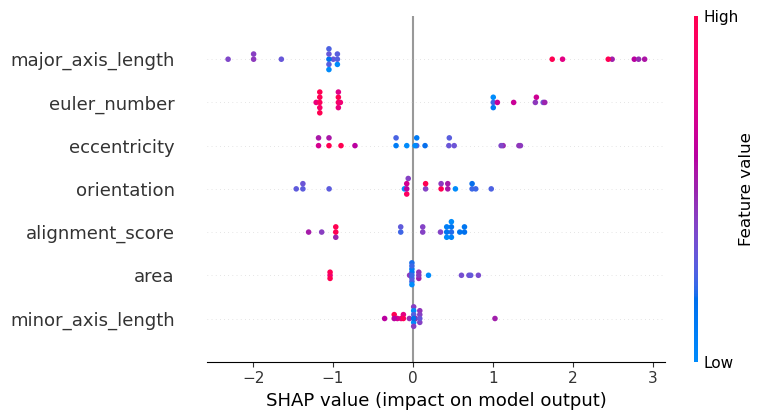

In [113]:
shap.summary_plot(shap_values,show=True)

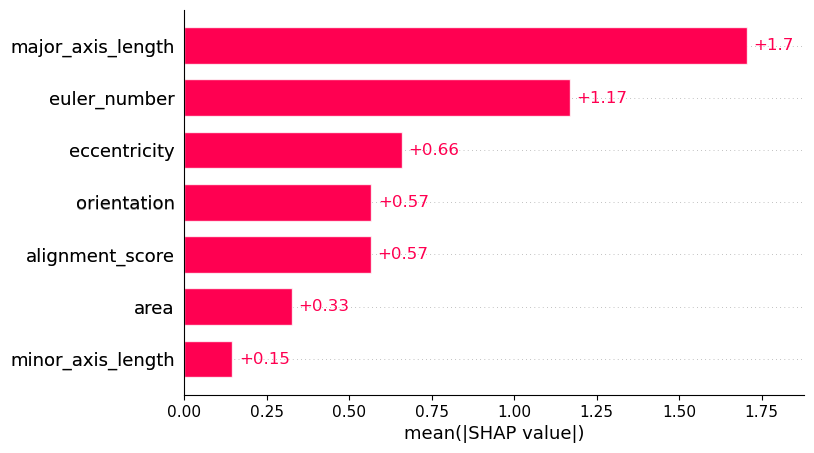

In [117]:
shap.plots.bar(shap_values,max_display=None)

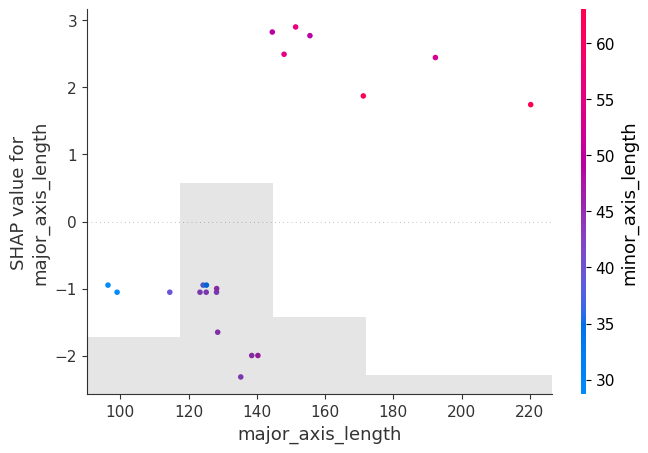

In [120]:
shap.plots.scatter(shap_values[:,'major_axis_length'], color=shap_values,show=True)
plt.tight_layout()
